## Evaluation on other sets

Load wav2vec, embed a dataset, predict emotions using the pretrained classifier.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Import from local modules
from config import EMOTION_DICT, USE_CUDA, MELD_FOLDER, MELD_EMOTION_LIST
from utils import load_ravdess_data, load_meld_data, check_emotion_distribution, extract_wave2vec_features
from models import (
    EmotionClassifier, prepare_data, create_dataloaders, train_model, 
    evaluate, analyze_training_quality, EMOTION_LABELS, IDX_TO_EMOTION
)

print(f"RAVDESS emotions: {list(EMOTION_DICT.values())}")
print(f"MELD emotions: {MELD_EMOTION_LIST}")

RAVDESS emotions: ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgusted', 'surprised']
MELD emotions: ['neutral', 'anger', 'disgust', 'sadness', 'joy', 'surprise', 'fear']


In [2]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


#### Import MELD dataset
 Contains dialogues from friends labelised with Anger, Disgust, Sadness, Joy, Neutral, Surprise and Fear. Unlike RAVDESS, the text is not neutral and carries an emotion on top of the utterance.

In [3]:


from pathlib import Path
from huggingface_hub import hf_hub_download, list_repo_files
import tarfile

# Create MELD_data directory if it doesn't exist
data_dir = Path("MELD_data")

if not (data_dir).is_dir():
    data_dir.mkdir(exist_ok=True)
    
    print("Downloading MELD dataset from Hugging Face...")
    
    try:
        repo_id = "ajyy/MELD_audio"
        
        # List all files in the repository
        print("Listing files in repository...")
        files = list_repo_files(repo_id=repo_id, repo_type="dataset")
        
        print(f"Found {len(files)} files total")
        
        # Download all files
        print(f"\nDownloading all files...")
        for idx, file_path in enumerate(files):
            if idx % 50 == 0:
                print(f"  {idx}/{len(files)} - {file_path}")
            
            try:
                # Download the file
                downloaded_path = hf_hub_download(
                    repo_id=repo_id,
                    filename=file_path,
                    repo_type="dataset",
                    local_dir=str(data_dir)
                )
            except Exception as e:
                print(f"    Warning: Could not download {file_path}: {e}")
                continue
        
        print(f"\nDownload complete!")
        print(f"Data saved to: {data_dir}")
        
        # List downloaded files
        total_count = len(list(data_dir.rglob('*.*')))
        print(f"Total files downloaded: {total_count}")
        
        # Extract tar.gz files
        print("\n" + "="*60)
        print("Extracting tar.gz files...")
        print("="*60)
        
        tar_files = list(data_dir.rglob('*.tar.gz'))
        print(f"Found {len(tar_files)} tar.gz files to extract")
        
        for tar_file in tar_files:
            print(f"\nExtracting: {tar_file.name}")
            try:
                with tarfile.open(tar_file, 'r:gz') as tar_ref:
                    tar_ref.extractall(data_dir)
                print(f"  Successfully extracted {tar_file.name}")
            except Exception as e:
                print(f"  Error extracting {tar_file.name}: {e}")
        
        print("\nExtraction complete!")
        
    except Exception as e:
        print(f"Error downloading dataset: {e}")
        print("Make sure the huggingface_hub library is installed: pip install huggingface-hub")
     # Check if tar.gz files exist and extract them
    tar_files = list(data_dir.rglob('*.tar.gz'))
    if tar_files:
        print(f"\nFound {len(tar_files)} tar.gz files to extract")
        print("="*60)
        print("Extracting tar.gz files...")
        print("="*60)
        
        for tar_file in tar_files:
            print(f"\nExtracting: {tar_file.name}")
            try:
                with tarfile.open(tar_file, 'r:gz') as tar_ref:
                    tar_ref.extractall(data_dir)
                print(f"  Successfully extracted {tar_file.name}")
            except Exception as e:
                print(f"  Error extracting {tar_file.name}: {e}")
        
        print("\nExtraction complete!")
    else:
        print("No tar.gz files found in MELD_data directory")

else:
    print("MELD data directory already exists")
    
   

Listing files in repository...
Found 9 files total

  0/9 - .gitattributes


.gitattributes: 0.00B [00:00, ?B/s]

MELD_audio.py: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

archive/dev.tar.gz:   0%|          | 0.00/121M [00:00<?, ?B/s]

...

archive/train.tar.gz:   0%|          | 0.00/1.09G [00:00<?, ?B/s]

dev.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]


Download complete!
Data saved to: MELD_data
Total files downloaded: 20

Extracting tar.gz files...
Found 3 tar.gz files to extract

Extracting: dev.tar.gz
  Successfully extracted dev.tar.gz

Extracting: test.tar.gz
  Successfully extracted test.tar.gz

Extracting: train.tar.gz
  Successfully extracted train.tar.gz

Extraction complete!

Found 3 tar.gz files to extract
Extracting tar.gz files...

Extracting: dev.tar.gz
  Successfully extracted dev.tar.gz

Extracting: test.tar.gz
  Successfully extracted test.tar.gz

Extracting: train.tar.gz
  Successfully extracted train.tar.gz

Extraction complete!


In [4]:
# Initialize Wave2Vec2 model and processor
import logging
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from transformers import logging as hf_logging
from config import WAVE2VEC2_MODEL

# Suppress quantizer warnings
hf_logging.set_verbosity_error()
logging.getLogger('transformers').setLevel(logging.ERROR)

print(f"Loading Wave2Vec2 model ({WAVE2VEC2_MODEL})...")
processor = Wav2Vec2Processor.from_pretrained(WAVE2VEC2_MODEL)
wave2vec_model = Wav2Vec2Model.from_pretrained(WAVE2VEC2_MODEL, weights_only=False).to(device)
wave2vec_model.eval()

print("Wave2Vec2 model loaded successfully!")
print(f"Model output dimension: 768 features per frame")
print(f"After aggregation: 3072 features (mean, std, max, min)")

# Initialize variables for data storage
X = []  # Feature vectors
y = []  # Emotion labels

Loading Wave2Vec2 model (facebook/wav2vec2-base)...


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 14975.35it/s]


Wave2Vec2 model loaded successfully!
Model output dimension: 768 features per frame
After aggregation: 3072 features (mean, std, max, min)


In [5]:
from utils import load_meld_data

print("Loading MELD subset")
print(f"MELD folder: {MELD_FOLDER}")

cache_path = os.path.join("MELD_data", "cache", "meld_train_subset_10000.npz")

if os.path.exists(cache_path):
    print(f"Loading cached embeddings from {cache_path}")
    cache = np.load(cache_path, allow_pickle=True)
    X_meld = [np.asarray(x, dtype=np.float32) for x in cache["X"]]
    y_meld = cache["y"].tolist()
else:
    print("Cache not found, extracting wav2vec embeddings...")
    X_meld, y_meld = load_meld_data(
        data_folder=MELD_FOLDER,
        processor=processor,
        wave2vec_model=wave2vec_model,
        device=device,
        split='train',
        max_samples=10000
    )

    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    np.savez_compressed(
        cache_path,
        X=np.asarray(X_meld, dtype=np.float32),
        y=np.asarray(y_meld, dtype=object)
    )
    print(f"Saved cache to {cache_path}")

print(f"Loaded {len(X_meld)} samples")

Loading MELD subset
MELD folder: MELD_data/
Loading cached embeddings from MELD_data\cache\meld_train_subset_10000.npz
Loaded 9988 samples


In [6]:
# Split data and normalize (scaler fit on training data only)
X_train, X_test, y_train, y_test, scaler = prepare_data(X_meld, y_meld, )

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Create data loaders
train_loader, test_loader = create_dataloaders(X_train, X_test, y_train, y_test)

# Initialize classifier model
model = EmotionClassifier(input_size=X_train.shape[1], num_emotions=len(EMOTION_LABELS)).to(device)

print(f"\nUsing device: {device}")
print(f"Emotion classifier initialized")
print(f"Input size (Wave2Vec2 features): {X_train.shape[1]}")
print(f"Model architecture: 4-layer network with batch normalization")


Data normalization complete. Scaler fit on training data only.

Training set size: 7990
Test set size: 1998

Using device: cuda
Emotion classifier initialized
Input size (Wave2Vec2 features): 3072
Model architecture: 4-layer network with batch normalization


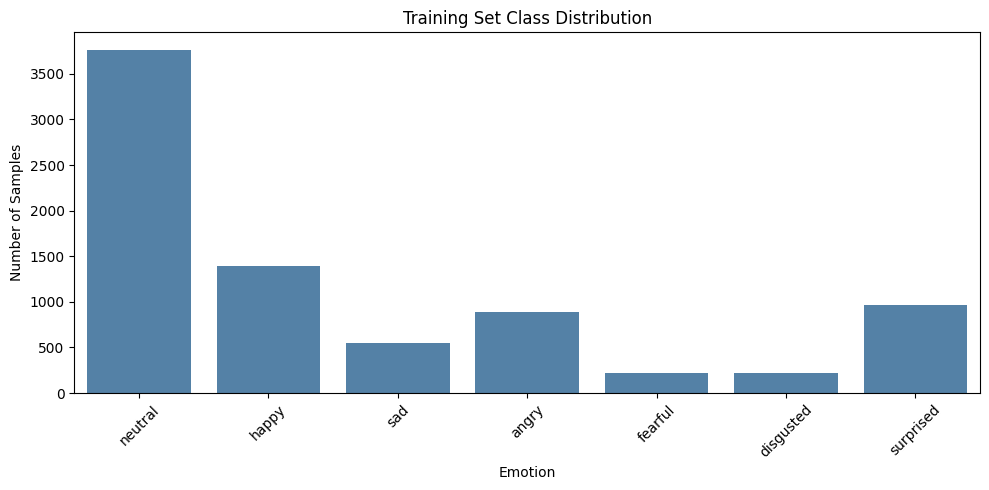

In [7]:
# Class distribution before training
class_counts = np.bincount(y_train, minlength=len(EMOTION_LABELS))
present_idx = np.where(class_counts > 0)[0]
labels = [IDX_TO_EMOTION[i] for i in present_idx]
counts = class_counts[present_idx]

plt.figure(figsize=(10, 5))
sns.barplot(x=labels, y=counts, color='steelblue')
plt.title('Training Set Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Train the model with class-balanced loss
print("training classifier...")

# Compute class weights from training labels (inverse frequency)
class_counts = np.bincount(y_train, minlength=len(EMOTION_LABELS))
class_weights = np.zeros_like(class_counts, dtype=np.float32)
nonzero = class_counts > 0
class_weights[nonzero] = len(y_train) / (len(class_counts) * class_counts[nonzero])
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("Class distribution:")
for idx, count in enumerate(class_counts):
    if count > 0:
        print(f"  {IDX_TO_EMOTION[idx]}: {count}")
print("Class weights:")
for idx, w in enumerate(class_weights):
    if class_counts[idx] > 0:
        print(f"  {IDX_TO_EMOTION[idx]}: {w:.3f}")

train_losses, train_accs, test_losses, test_accs = train_model(
    model,
    train_loader,
    test_loader,
    device,
    class_weights=class_weights_tensor
)

# Analyze training quality
analyze_training_quality(y_train, train_losses, test_losses)

training classifier...
Class distribution:
  neutral: 3767
  happy: 1394
  sad: 546
  angry: 887
  fearful: 215
  disgusted: 217
  surprised: 964
Class weights:
  neutral: 0.265
  happy: 0.716
  sad: 1.829
  angry: 1.126
  fearful: 4.645
  disgusted: 4.603
  surprised: 1.036
Training Emotion Classifier on cuda...



 33%|███▎      | 10/30 [00:54<01:56,  5.84s/it]

Epoch [10/30]
  Train Loss: 1.8037, Accuracy: 23.24%
  Test Loss: 1.8859, Accuracy: 20.97%



 67%|██████▋   | 20/30 [01:45<00:49,  4.97s/it]

Epoch [20/30]
  Train Loss: 1.5291, Accuracy: 27.32%
  Test Loss: 2.0916, Accuracy: 22.57%



100%|██████████| 30/30 [02:35<00:00,  5.17s/it]

Epoch [30/30]
  Train Loss: 1.3305, Accuracy: 32.95%
  Test Loss: 2.3081, Accuracy: 26.43%

Training complete!

Train loss improvement: 34.1%
Test loss stable (change: 21.1%)


True

In [9]:
# Save the trained MELD model
print("\n" + "="*60)
print("Saving Model")
print("="*60)

os.makedirs("models", exist_ok=True)
model_save_path = "models/MELDemotionClassifier.pth"
torch.save(model, model_save_path)
print(f"\nMELD model saved to: {model_save_path}")


Saving Model

MELD model saved to: models/MELDemotionClassifier.pth


STEP 6: Results and Visualization


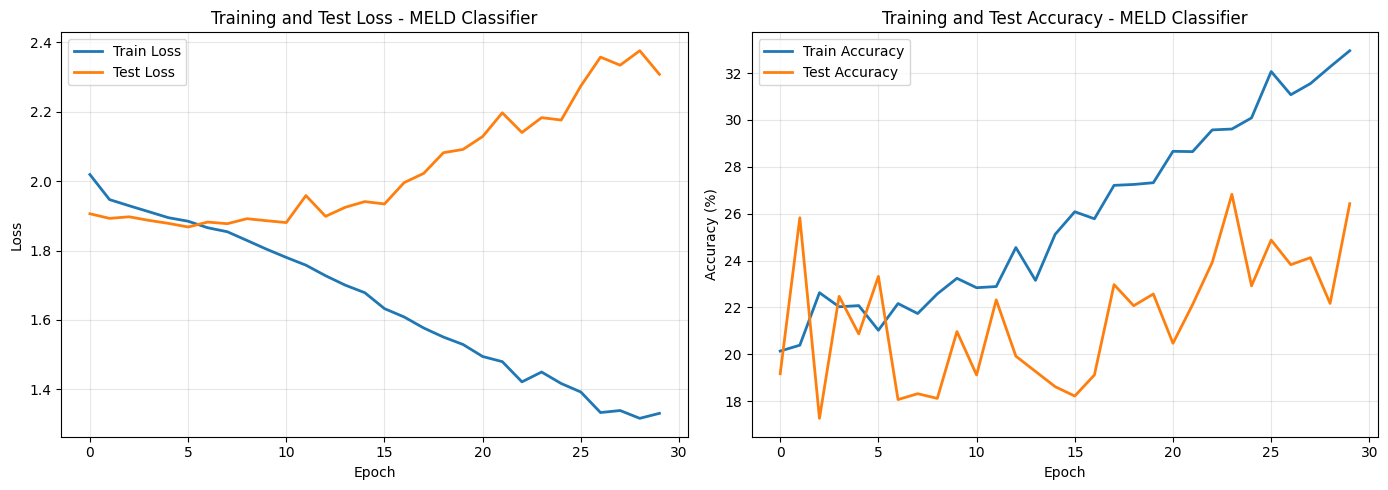


Final Test Accuracy on MELD: 26.43%
Emotions in evaluation: ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgusted', 'surprised']


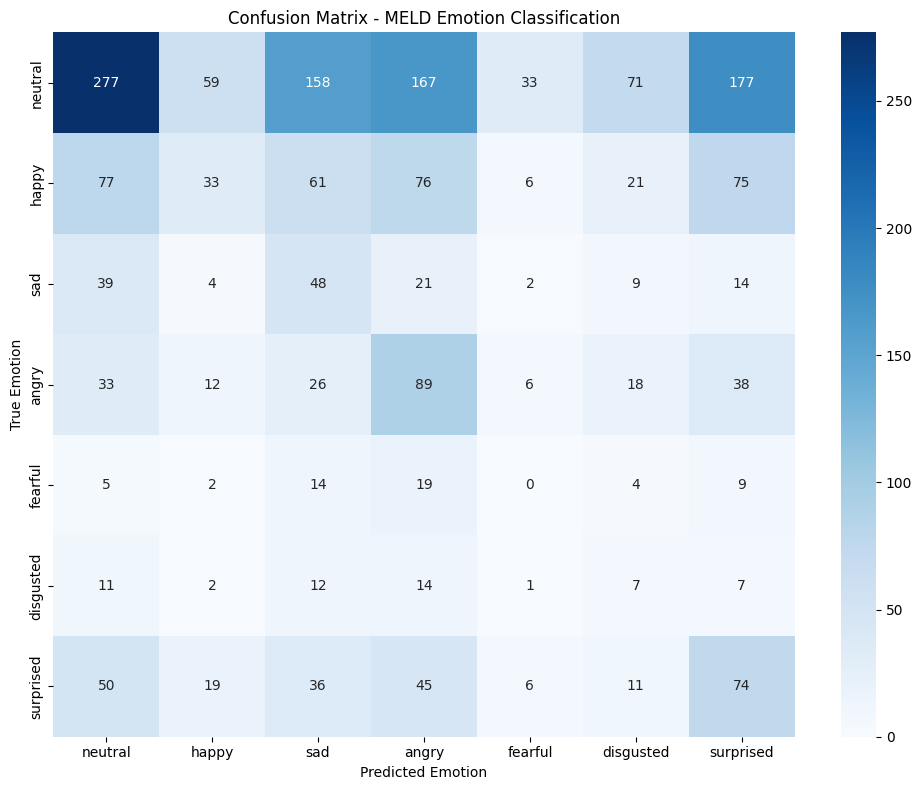


Classification Report:
              precision    recall  f1-score   support

     neutral       0.56      0.29      0.39       942
       happy       0.25      0.09      0.14       349
         sad       0.14      0.35      0.20       137
       angry       0.21      0.40      0.27       222
     fearful       0.00      0.00      0.00        53
   disgusted       0.05      0.13      0.07        54
   surprised       0.19      0.31      0.23       241

    accuracy                           0.26      1998
   macro avg       0.20      0.23      0.19      1998
weighted avg       0.37      0.26      0.28      1998



In [10]:
# Visualize training results
print("="*60)
print("STEP 6: Results and Visualization")
print("="*60)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Test Loss - MELD Classifier')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(train_accs, label='Train Accuracy', linewidth=2)
axes[1].plot(test_accs, label='Test Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Test Accuracy - MELD Classifier')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final evaluation
criterion = nn.CrossEntropyLoss()
_, final_acc, all_preds, all_labels = evaluate(model, test_loader, criterion, device)
print(f"\nFinal Test Accuracy on MELD: {final_acc:.2f}%")

# Convert index predictions/labels back to emotion names
true_emotions = [IDX_TO_EMOTION[idx] for idx in all_labels]
pred_emotions = [IDX_TO_EMOTION[idx] for idx in all_preds]

# Keep a stable order following config labels; include only labels present in eval
present_emotions = [
    emotion for emotion in EMOTION_LABELS
    if emotion in set(true_emotions) or emotion in set(pred_emotions)
]

print(f"Emotions in evaluation: {present_emotions}")

# Confusion Matrix
cm = confusion_matrix(true_emotions, pred_emotions, labels=present_emotions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=present_emotions,
    yticklabels=present_emotions
)
plt.title('Confusion Matrix - MELD Emotion Classification')
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        true_emotions,
        pred_emotions,
        labels=present_emotions,
        target_names=present_emotions,
        zero_division=0
    )
)

### Training Results and Visualization